#Manual Linear Regression



- Y=WX+B

w = slope

b = intercept

x = input

y = prediction

-------------------

- Cost Function

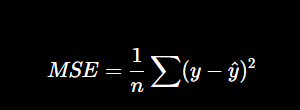


- Gradient

	​

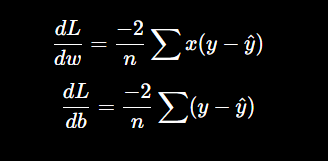



Update weights


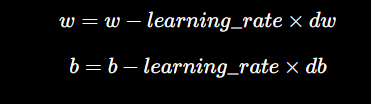

In [3]:
import numpy as np
import matplotlib.pyplot as plt


# =========================
# 1. Data
# =========================

X = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 6, 8, 10])


# =========================
# 2. Initial values
# =========================

w = 0
b = 0

learning_rate = 0.01
epochs = 1000


# =========================
# 3. Training
# =========================

for epoch in range(epochs):

    # Prediction
    y_pred = w * X + b

    # Loss
    loss = np.mean((y - y_pred) ** 2)

    # Gradients
    dw = (-2 / len(X)) * np.sum(X * (y - y_pred))
    db = (-2 / len(X)) * np.sum(y - y_pred)

    # Update weights
    w = w - learning_rate * dw
    b = b - learning_rate * db

    # Print loss
    if epoch % 100 == 0:
        print("Epoch:", epoch, "Loss:", loss)









Epoch: 0 Loss: 44.0
Epoch: 100 Loss: 0.02447442684930146
Epoch: 200 Loss: 0.012432209885934168
Epoch: 300 Loss: 0.006315156779752394
Epoch: 400 Loss: 0.0032078934894731645
Epoch: 500 Loss: 0.001629505172824526
Epoch: 600 Loss: 0.0008277354335408341
Epoch: 700 Loss: 0.0004204625792941973
Epoch: 800 Loss: 0.00021358126452370824
Epoch: 900 Loss: 0.00010849231014117063


In [4]:
# =========================
# 4. Final parameters
# =========================

print("\nFinal w:", w)
print("Final b:", b)


Final w: 1.9951803506719779
Final b: 0.017400463340610635


In [5]:
# =========================
# 5. Prediction
# =========================

x_new = 6

prediction = w * x_new + b

print("Prediction for x=6:", prediction)


Prediction for x=6: 11.988482567372477


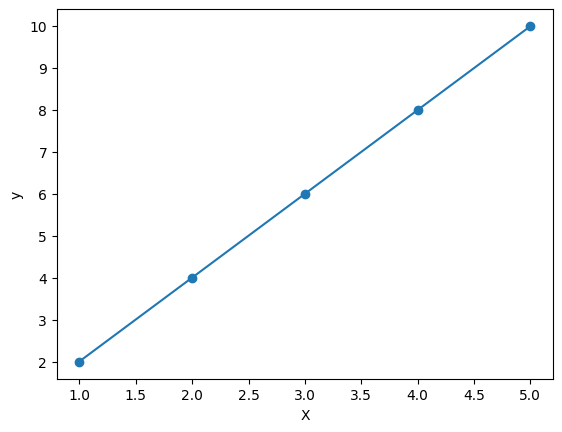

In [6]:
# =========================
# 6. Plot
# =========================

plt.scatter(X, y)

plt.plot(X, w * X + b)

plt.xlabel("X")
plt.ylabel("y")

plt.show()

---------------------------------

In [7]:
import numpy as np


class LinearRegression:

    def __init__(self, learning_rate=0.01, epochs=1000, tolerance=0.000001):

        self.learning_rate = learning_rate
        self.epochs = epochs
        self.tolerance = tolerance

        self.w = 0
        self.b = 0

    # -------------------------
    # Prediction
    # -------------------------

    def predict(self, X):

        return self.w * X + self.b

    # -------------------------
    # Training
    # -------------------------

    def fit(self, X, y):

        previous_loss = float("inf")

        for epoch in range(self.epochs):

            # 1. Prediction
            y_pred = self.predict(X)

            # 2. Calculate Loss
            loss = np.mean((y - y_pred) ** 2)

            # 3. Calculate Gradients
            dw = (-2 / len(X)) * np.sum(X * (y - y_pred))

            db = (-2 / len(X)) * np.sum(y - y_pred)

            # Save old values
            old_w = self.w
            old_b = self.b

            # 4. Update weights
            self.w = self.w - self.learning_rate * dw
            self.b = self.b - self.learning_rate * db

            # -------------------------
            # Stopping conditions
            # -------------------------

            # Condition 1:
            # Loss is almost not changing
            if abs(previous_loss - loss) < self.tolerance:

                print("Training stopped: Loss is not changing.")

                break

            # Condition 2:
            # w and b are almost not changing
            if abs(self.w - old_w) < self.tolerance and \
               abs(self.b - old_b) < self.tolerance:

                print("Training stopped: Weights are not changing.")

                break

            previous_loss = loss

            # Print progress
            if epoch % 100 == 0:

                print(
                    "Epoch:", epoch,
                    "Loss:", loss,
                    "w:", self.w,
                    "b:", self.b
                )

        print("\nTraining Finished!")
        print("Final w:", self.w)
        print("Final b:", self.b)

    # -------------------------
    # Loss
    # -------------------------

    def calculate_loss(self, X, y):

        y_pred = self.predict(X)

        loss = np.mean((y - y_pred) ** 2)

        return loss

In [8]:
X = np.array([1, 2, 3, 4, 5])

y = np.array([2, 4, 6, 8, 10])


model = LinearRegression(
    learning_rate=0.01,
    epochs=1000
)


model.fit(X, y)

Epoch: 0 Loss: 44.0 w: 0.44 b: 0.12
Epoch: 100 Loss: 0.02447442684930146 w: 1.898775997753122 b: 0.36545076630285395
Epoch: 200 Loss: 0.012432209885934168 w: 1.927855802591494 b: 0.26046344387458364
Epoch: 300 Loss: 0.006315156779752394 w: 1.9485815112589555 b: 0.18563705935329852
Epoch: 400 Loss: 0.0032078934894731645 w: 1.9633531028220825 b: 0.13230692680978884
Epoch: 500 Loss: 0.001629505172824526 w: 1.9738810862463791 b: 0.09429756613702703
Epoch: 600 Loss: 0.0008277354335408341 w: 1.9813845725503834 b: 0.06720759973626017
Epoch: 700 Loss: 0.0004204625792941973 w: 1.9867324444499956 b: 0.04790008530809561
Epoch: 800 Loss: 0.00021358126452370824 w: 1.9905439705454586 b: 0.034139266712792826
Training stopped: Loss is not changing.

Training Finished!
Final w: 1.9921775491826919
Final b: 0.028241529500685696


In [9]:
prediction = model.predict(6)

print("Prediction:", prediction)

Prediction: 11.981306824596837
